<a href="https://colab.research.google.com/github/St1CkBSPL/PF174712/blob/main/LAB3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Wszystko gotowe!
Załadowano 350 polskich stop words.


Saving recenzje_filmowe.csv to recenzje_filmowe (9).csv


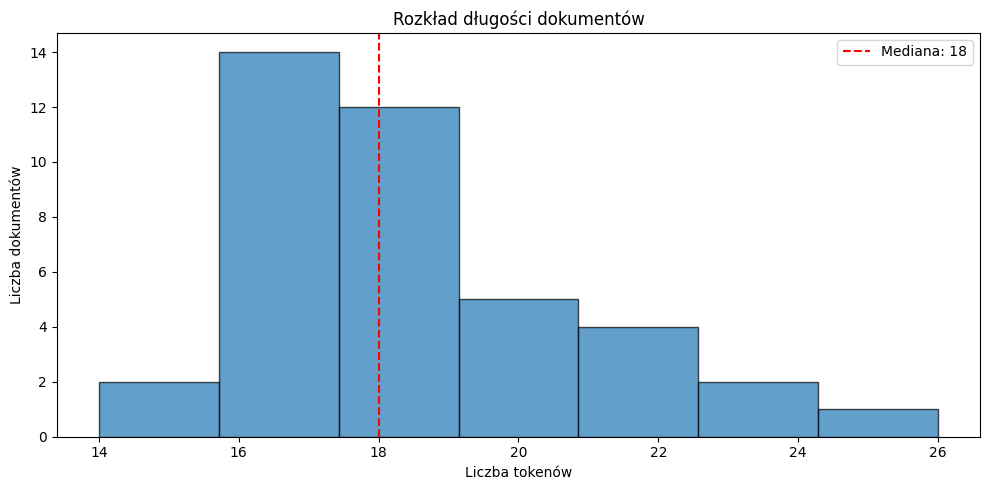

In [21]:
!pip install nltk wordcloud matplotlib pandas --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
from collections import Counter

import nltk
nltk.download('punkt_tab', quiet=True)
from nltk.tokenize import word_tokenize
from nltk import ngrams
from wordcloud import WordCloud

# Polskie stop words — pobieramy z internetu
import urllib.request
url = "https://raw.githubusercontent.com/bieli/stopwords/master/polish.stopwords.txt"
response = urllib.request.urlopen(url)
stop_pl = set(response.read().decode("utf-8").splitlines())

print("Wszystko gotowe!")
print(f"Załadowano {len(stop_pl)} polskich stop words.")


from google.colab import files
uploaded = files.upload()
df = pd.read_csv("recenzje_filmowe.csv")

df.shape
df.columns
df.dtypes
df.head()
df["text"].head(3)
df["tokens"] = df["text"].apply(lambda x: word_tokenize(x, language="polish"))
df["n_tokens"] = df["tokens"].apply(len)

plt.figure(figsize=(10, 5))
plt.hist(df["n_tokens"], bins="auto", edgecolor="black", alpha=0.7)
plt.xlabel("Liczba tokenów")
plt.ylabel("Liczba dokumentów")
plt.title("Rozkład długości dokumentów")
plt.axvline(df["n_tokens"].median(), color="red", linestyle="--", label=f"Mediana: {df['n_tokens'].median():.0f}")
plt.legend()
plt.tight_layout()
plt.show()